# Encoder Metrics

This notebook should be used while attached to Encoder Docker container to run properly

In [1]:
from transformers import AlignProcessor, AlignModel
from typing import Literal
import torch

device = "cpu"
processor = AlignProcessor.from_pretrained("kakaobrain/align-base")
model = AlignModel.from_pretrained("kakaobrain/align-base").to(device)

def get_embedding(inputs, type: Literal["text", "image"] = "image") -> torch.Tensor:
    with torch.no_grad():
        if type == "text":
            text_inputs = processor.tokenizer(
                inputs,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=64
            ).to(device)

            outputs = model.get_text_features(
                input_ids=text_inputs['input_ids'],
                attention_mask=text_inputs['attention_mask'],
                token_type_ids=text_inputs['token_type_ids']
            )
        elif type == "image":
            image_inputs = processor(
                images=inputs,
                return_tensors="pt"
            ).to(device)

            outputs = model.get_image_features(pixel_values=image_inputs['pixel_values'])
    
    if hasattr(outputs, "pooler_output"):
        outputs = outputs.pooler_output

    embedding = outputs / outputs.norm(dim=-1, keepdim=True)  # [1, D]
    embedding = embedding.cpu().tolist()[0]

    return embedding


In [2]:
!ls ../data/nuimages/

LICENSE				samples    v1.0-test
nuimages-v1.0-all-metadata.tgz	sweeps	   v1.0-train
nuimages-v1.0-all-samples.tgz	v1.0-mini  v1.0-val


In [3]:
import json
from collections import defaultdict

ROOT = "../data/nuimages"
META = f"{ROOT}/v1.0-train"

# --- load ---
object_ann = json.load(open(f"{META}/object_ann.json"))
category = {c["token"]: c["name"] for c in json.load(open(f"{META}/category.json"))}
attribute = {a["token"]: a["name"] for a in json.load(open(f"{META}/attribute.json"))}
sample_data = {s["token"]: s for s in json.load(open(f"{META}/sample_data.json"))}


# --- normalize helpers ---
def norm_cat(cat):
    # vehicle.car → car
    return cat.split('.')[-1]

def norm_attr(attr):
    # vehicle.moving → moving
    return attr.split('.')[-1]


# --- collect objects per image ---
image_to_objs = defaultdict(list)

for ann in object_ann:
    sd_token = ann["sample_data_token"]

    cat = norm_cat(category[ann["category_token"]])
    attrs = [norm_attr(attribute[t]) for t in ann["attribute_tokens"]]

    image_to_objs[sd_token].append((cat, tuple(sorted(attrs))))


# --- build clean text ---
def build_text(objs):
    """
    objs: list[(cat, attrs)]
    """

    # агрегируем: (cat, attrs) → count
    counter = defaultdict(int)
    for cat, attrs in objs:
        counter[(cat, attrs)] += 1

    parts = []

    for (cat, attrs), count in counter.items():
        # plural если >1
        name = cat if count == 1 else f"{cat}s"

        if attrs:
            attr_str = ", ".join(attrs)
            parts.append(f"{name} ({attr_str})")
        else:
            parts.append(name)

    # сортировка для стабильности
    parts = sorted(parts)

    # финальный текст
    return "A scene with " + ", ".join(parts) + "."


# --- build dataset ---
dataset = []

for sd_token, objs in image_to_objs.items():
    path = sample_data[sd_token]["filename"]

    dataset.append({
        "image_path": f"{ROOT}/{path}",
        "text": build_text(objs)
    })

print(f"Dataset size: {len(dataset)}")
print(dataset[:3])

Dataset size: 60668
[{'image_path': '../data/nuimages/samples/CAM_BACK/n010-2018-08-27-16-15-24+0800__CAM_BACK__1535357859787257.jpg', 'text': 'A scene with barriers, cars (moving), construction (parked), construction_worker (moving), construction_workers (standing), trafficcones, trucks (parked).'}, {'image_path': '../data/nuimages/samples/CAM_BACK_LEFT/n009-2018-09-12-09-59-51-0400__CAM_BACK_LEFT__1536761455547158.jpg', 'text': 'A scene with adults (moving), cars (parked), debris, trafficcones, truck (parked).'}, {'image_path': '../data/nuimages/samples/CAM_BACK/n003-2018-01-08-11-30-34+0800__CAM_BACK__1515383180607961.jpg', 'text': 'A scene with adults (moving), bicycles (without_rider), car (moving).'}]


In [9]:
!pip install -U ipywidgets jupyterlab_widgets

In [24]:
import json
import numpy as np
from collections import defaultdict, Counter
from tqdm import tqdm
from PIL import Image

# CONFIG
ROOT = "../data/nuimages"
META = f"{ROOT}/v1.0-train"
LIMIT = 10000
TOP_K_CLASSES = 100

# LOAD
object_ann = json.load(open(f"{META}/object_ann.json"))
category = {c["token"]: c["name"] for c in json.load(open(f"{META}/category.json"))}
sample_data = {s["token"]: s for s in json.load(open(f"{META}/sample_data.json"))}

def norm_cat(cat):
    return cat.split('.')[-1]

# BUILD DATA
image_to_objs = defaultdict(list)

for ann in object_ann:
    sd_token = ann["sample_data_token"]
    cat = norm_cat(category[ann["category_token"]])
    image_to_objs[sd_token].append(cat)

dataset = []
for sd_token, cats in image_to_objs.items():
    path = sample_data[sd_token]["filename"]
    dataset.append({
        "image_path": f"{ROOT}/{path}",
        "classes": set(cats)
    })

print("Dataset size:", len(dataset))

# CLASS DISTRIBUTION
counter = Counter()

for item in dataset:
    for c in item["classes"]:
        counter[c] += 1

CLASSES = [c for c, _ in counter.most_common(TOP_K_CLASSES)]

print("\nTop classes:")
for c in CLASSES[:20]:
    print(f"{c}: {counter[c]}")

# EMBEDDINGS
def compute_image_embeddings(dataset, limit=None):
    image_embs = []

    for i, item in enumerate(tqdm(dataset, desc="Images")):
        img = Image.open(item["image_path"]).convert("RGB")
        emb = get_embedding(img, type="image")
        image_embs.append(emb)

        if limit and i >= limit:
            break

    image_embs = np.stack(image_embs)
    image_embs /= np.linalg.norm(image_embs, axis=1, keepdims=True)
    return image_embs


# METRICS
def evaluate_class(sim, labels, k):
    order = np.argsort(-sim)
    top_k = order[:k]

    recall = labels[top_k].sum() / labels.sum() if labels.sum() > 0 else 0
    precision = labels[top_k].sum() / k

    rel = labels[order[:k]]
    dcg = sum(r / np.log2(i + 2) for i, r in enumerate(rel))
    idcg = sum(1 / np.log2(i + 2) for i in range(min(k, int(labels.sum()))))
    ndcg = dcg / idcg if idcg > 0 else 0

    return recall, precision, ndcg

# EVAL
def evaluate_all_classes(dataset, image_embs, classes, k_list):
    results = {}
    dataset = dataset[:len(image_embs)]

    for cls in classes:
        freq = counter[cls]

        print(f"\n=== CLASS: {cls} (count={freq}) ===")

        text_emb = get_embedding(f"photo of a {cls}", type="text")
        text_emb /= np.linalg.norm(text_emb)

        sim = image_embs @ text_emb

        labels = np.array([
            1 if cls in item["classes"] else 0
            for item in dataset
        ])

        results[cls] = {}

        for k in k_list:
            recall, precision, ndcg = evaluate_class(sim, labels, k)

            print(f"K={k}: Recall={recall:.3f}, Precision={precision:.3f}, nDCG={ndcg:.3f}")

            results[cls][k] = {
                "recall": recall,
                "precision": precision,
                "ndcg": ndcg
            }

    return results


K_LIST = [1, 5, 10, 20, 50]
image_embs = compute_image_embeddings(dataset, LIMIT)

results = evaluate_all_classes(dataset, image_embs, CLASSES, K_LIST)

Dataset size: 60668

Top classes:
car: 45620
adult: 32442
truck: 19062
trafficcone: 17668
barrier: 10865
motorcycle: 10193
bicycle: 9542
rigid: 5564
construction_worker: 4367
construction: 4147
bicycle_rack: 2223
pushable_pullable: 2114
trailer: 1920
debris: 1451
child: 871
personal_mobility: 635
police_officer: 289
stroller: 273
animal: 142
bendy: 130


Images:  16%|███████                                    | 10000/60668 [20:55<1:45:59,  7.97it/s]



=== CLASS: car (count=45620) ===
K=1: Recall=0.000, Precision=1.000, nDCG=1.000
K=5: Recall=0.001, Precision=1.000, nDCG=1.000
K=10: Recall=0.001, Precision=1.000, nDCG=1.000
K=20: Recall=0.002, Precision=1.000, nDCG=1.000
K=50: Recall=0.006, Precision=1.000, nDCG=1.000

=== CLASS: adult (count=32442) ===
K=1: Recall=0.000, Precision=1.000, nDCG=1.000
K=5: Recall=0.000, Precision=0.600, nDCG=0.699
K=10: Recall=0.001, Precision=0.800, nDCG=0.805
K=20: Recall=0.002, Precision=0.800, nDCG=0.806
K=50: Recall=0.006, Precision=0.820, nDCG=0.819

=== CLASS: truck (count=19062) ===
K=1: Recall=0.000, Precision=1.000, nDCG=1.000
K=5: Recall=0.001, Precision=0.800, nDCG=0.830
K=10: Recall=0.002, Precision=0.800, nDCG=0.821
K=20: Recall=0.004, Precision=0.850, nDCG=0.849
K=50: Recall=0.010, Precision=0.900, nDCG=0.890

=== CLASS: trafficcone (count=17668) ===
K=1: Recall=0.000, Precision=1.000, nDCG=1.000
K=5: Recall=0.001, Precision=0.800, nDCG=0.854
K=10: Recall=0.002, Precision=0.800, nDCG=0.

In [27]:
K_LIST = [1, 5, 10, 20, 50, 100]
results = evaluate_all_classes(dataset, image_embs, CLASSES, K_LIST)


=== CLASS: car (count=45620) ===
K=1: Recall=0.000, Precision=1.000, nDCG=1.000
K=5: Recall=0.001, Precision=1.000, nDCG=1.000
K=10: Recall=0.001, Precision=1.000, nDCG=1.000
K=20: Recall=0.002, Precision=1.000, nDCG=1.000
K=50: Recall=0.006, Precision=1.000, nDCG=1.000
K=100: Recall=0.012, Precision=1.000, nDCG=1.000

=== CLASS: adult (count=32442) ===
K=1: Recall=0.000, Precision=1.000, nDCG=1.000
K=5: Recall=0.000, Precision=0.600, nDCG=0.699
K=10: Recall=0.001, Precision=0.800, nDCG=0.805
K=20: Recall=0.002, Precision=0.800, nDCG=0.806
K=50: Recall=0.006, Precision=0.820, nDCG=0.819
K=100: Recall=0.013, Precision=0.840, nDCG=0.835

=== CLASS: truck (count=19062) ===
K=1: Recall=0.000, Precision=1.000, nDCG=1.000
K=5: Recall=0.001, Precision=0.800, nDCG=0.830
K=10: Recall=0.002, Precision=0.800, nDCG=0.821
K=20: Recall=0.004, Precision=0.850, nDCG=0.849
K=50: Recall=0.010, Precision=0.900, nDCG=0.890
K=100: Recall=0.021, Precision=0.900, nDCG=0.895

=== CLASS: trafficcone (count=17

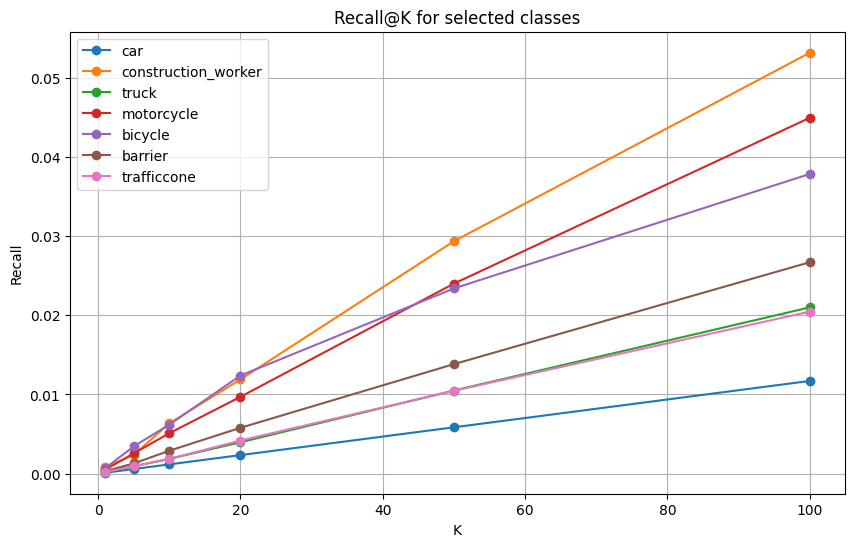

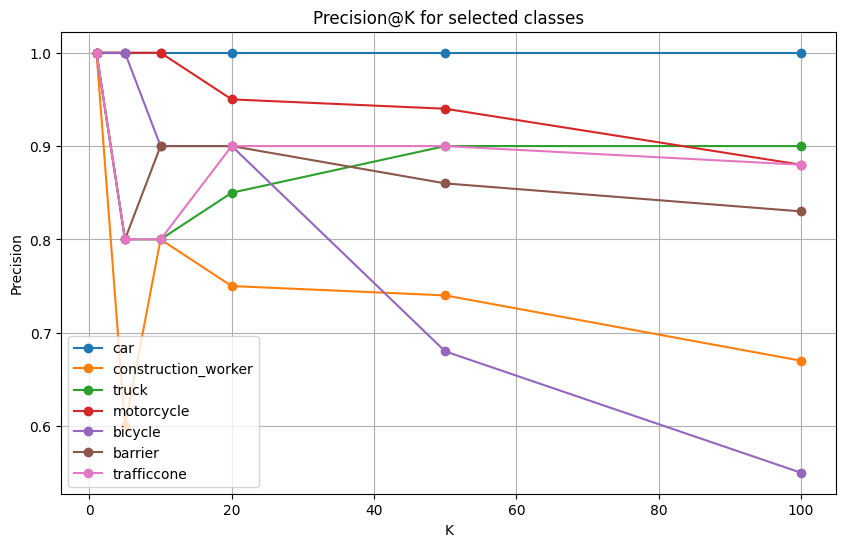

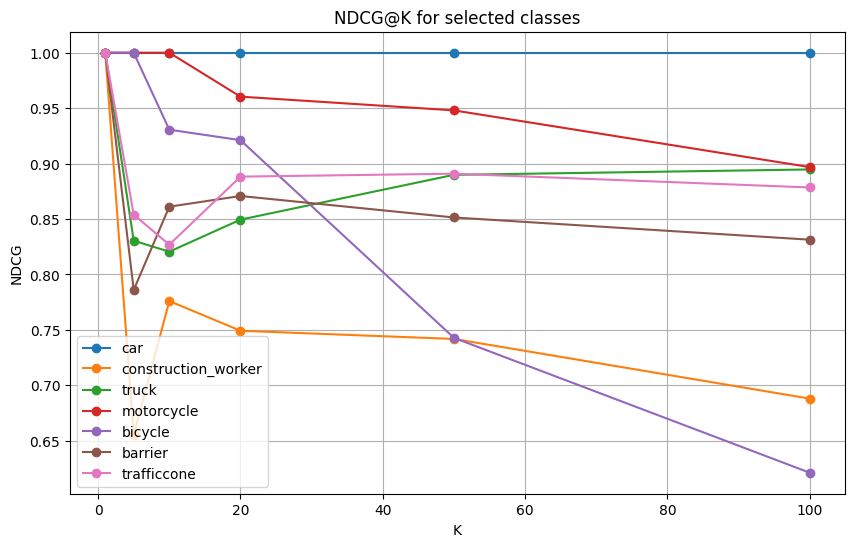

In [30]:
import matplotlib.pyplot as plt

SELECTED_CLASSES = ["car", "construction_worker", "truck", "motorcycle", "bicycle", "barrier", "trafficcone"]

def plot_metrics(results, classes, metric="recall"):
    plt.figure(figsize=(10, 6))

    for cls in classes:
        if cls not in results:
            continue

        ks = sorted(results[cls].keys())
        values = [results[cls][k][metric.lower()] for k in ks]

        plt.plot(ks, values, marker='o', label=cls)

    plt.xlabel("K")
    plt.ylabel(metric)
    plt.title(f"{metric}@K for selected classes")
    plt.legend()
    plt.grid(True)

    plt.show()


plot_metrics(results, SELECTED_CLASSES, metric="Recall")
plot_metrics(results, SELECTED_CLASSES, metric="Precision")
plot_metrics(results, SELECTED_CLASSES, metric="NDCG")

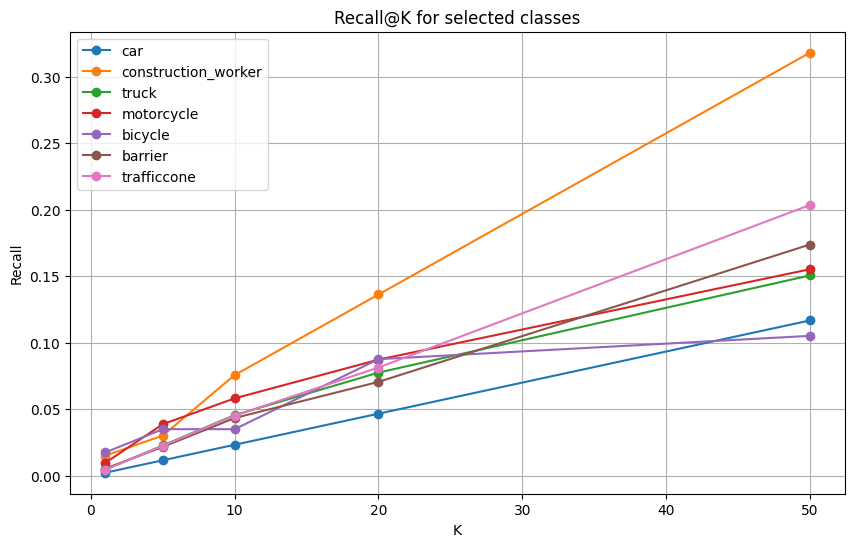

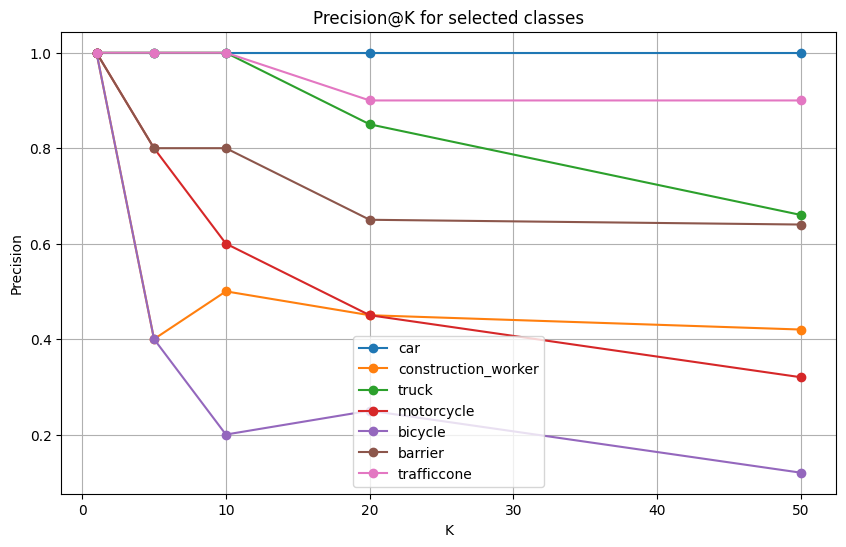

In [23]:
import matplotlib.pyplot as plt

SELECTED_CLASSES = ["car", "construction_worker", "truck", "motorcycle", "bicycle", "barrier", "trafficcone"]

def plot_metrics(results, classes, metric="recall"):
    plt.figure(figsize=(10, 6))

    for cls in classes:
        if cls not in results:
            continue

        ks = sorted(results[cls].keys())
        values = [results[cls][k][metric] for k in ks]

        plt.plot(ks, values, marker='o', label=cls)

    plt.xlabel("K")
    plt.ylabel(metric.capitalize())
    plt.title(f"{metric.capitalize()}@K for selected classes")
    plt.legend()
    plt.grid(True)

    plt.show()


plot_metrics(results, SELECTED_CLASSES, metric="recall")
plot_metrics(results, SELECTED_CLASSES, metric="precision")
plot_metrics(results, SELECTED_CLASSES, metric="NDCG")